### Netflix sentiment analysis
1. Using maching learning models(Classification) transformers, bert, logistic regression classify reviews
2. EDA - remove the duplication, check verified watchers. Remove null values
3. Feature Engineer - Feature selection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
data = pd.read_csv('reviews.csv')
print("Dataset loaded successfully.")

# Display basic information about the dataset
print("First 5 rows of the dataset:")
data.head()

Dataset loaded successfully.
First 5 rows of the dataset:


,review_id,user_id,movie_id,rating,review_date,device_type,is_verified_watch,helpful_votes,total_votes,review_text,sentiment,sentiment_score
0,review_000001,user_07066,movie_0360,4,2025-03-29,Mobile,False,3.0,5.0,Fantastic cinematography and plot twists.,positive,0.711
1,review_000002,user_02953,movie_0095,5,2024-07-19,Mobile,True,2.0,2.0,This series is a masterpiece!,positive,0.645
2,review_000003,user_05528,movie_0518,4,2025-02-11,Tablet,True,2.0,5.0,Fantastic cinematography and plot twists.,positive,0.730
3,review_000004,user_07612,movie_0672,5,2025-11-26,Mobile,True,7.0,7.0,One of the best series I've ever watched. High...,positive,0.798
4,review_000005,user_03424,movie_0580,3,2025-07-11,Mobile,True,1.0,5.0,Mixed feelings about this one.,neutral,0.410


In [2]:
print("Dataset Information:")
data.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15450 entries, 0 to 15449
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   review_id          15450 non-null  object 
 1   user_id            15450 non-null  object 
 2   movie_id           15450 non-null  object 
 3   rating             15450 non-null  int64  
 4   review_date        15450 non-null  object 
 5   device_type        15450 non-null  object 
 6   is_verified_watch  15450 non-null  bool   
 7   helpful_votes      13635 non-null  float64
 8   total_votes        13635 non-null  float64
 9   review_text        14665 non-null  object 
 10  sentiment          15450 non-null  object 
 11  sentiment_score    14241 non-null  float64
dtypes: bool(1), float64(3), int64(1), object(7)
memory usage: 1.3+ MB


In [3]:
print("Statistical Summary:")
data.describe()

Statistical Summary:


,rating,helpful_votes,total_votes,sentiment_score
count,15450.000000,13635.000000,13635.000000,14241.000000
mean,3.661165,3.000807,5.362010,0.635582
std,1.111063,1.728214,2.016783,0.246775
min,1.000000,0.000000,0.000000,0.000000
25%,3.000000,2.000000,4.000000,0.482000
50%,4.000000,3.000000,5.000000,0.668000
75%,5.000000,4.000000,7.000000,0.835000
max,5.000000,13.000000,16.000000,1.000000


In [4]:
print("###Checking for missing values, duplicates, unique values, column names, and data types:")
print("Number of missing values in each column:")
print(data.isnull().sum())
print("")
print("Number of duplicate rows:")
print(data.duplicated().sum())
print("")
print("Number of unique values in each column:")
print(data.nunique())
print("")
print("Column names:")
print(data.columns)
print("")
print("Data types of each column:")
print(data.dtypes)

###Checking for missing values, duplicates, unique values, column names, and data types:
Number of missing values in each column:
review_id               0
user_id                 0
movie_id                0
rating                  0
review_date             0
device_type             0
is_verified_watch       0
helpful_votes        1815
total_votes          1815
review_text           785
sentiment               0
sentiment_score      1209
dtype: int64

Number of duplicate rows:
450

Number of unique values in each column:
review_id            15000
user_id               7761
movie_id              1000
rating                   5
review_date            731
device_type              4
is_verified_watch        2
helpful_votes           14
total_votes             17
review_text             30
sentiment                3
sentiment_score        999
dtype: int64

Column names:
Index(['review_id', 'user_id', 'movie_id', 'rating', 'review_date',
       'device_type', 'is_verified_watch', 'helpful_v

### Exploratory Data Analysis

In [5]:
#remove duplicates
new_data = data.drop_duplicates()
print("###Removing duplicates from the dataset:")
print("Original shape of the dataset:", data.shape)
print("Duplicates removed. New shape of the dataset:", new_data.shape)

###Removing duplicates from the dataset:
Original shape of the dataset: (15450, 12)
Duplicates removed. New shape of the dataset: (15000, 12)


C:\Users\User\AppData\Local\Temp\ipykernel_2460\1439104004.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=new_data, palette='viridis')


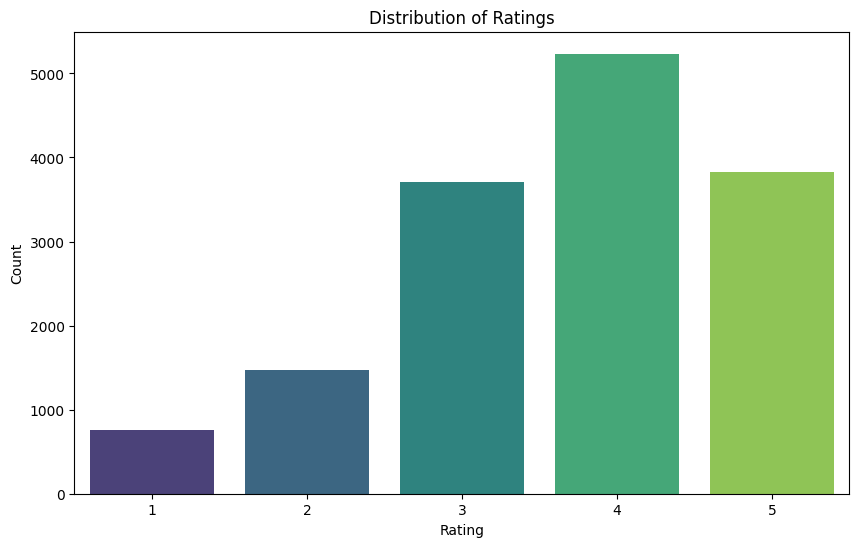

In [6]:
# Visualize the distribution of ratings
plt.figure(figsize=(10, 6))
sns.countplot(x='rating', data=new_data, palette='viridis')
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_2460\2067895264.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_verified_watch', data=new_data, palette='viridis')


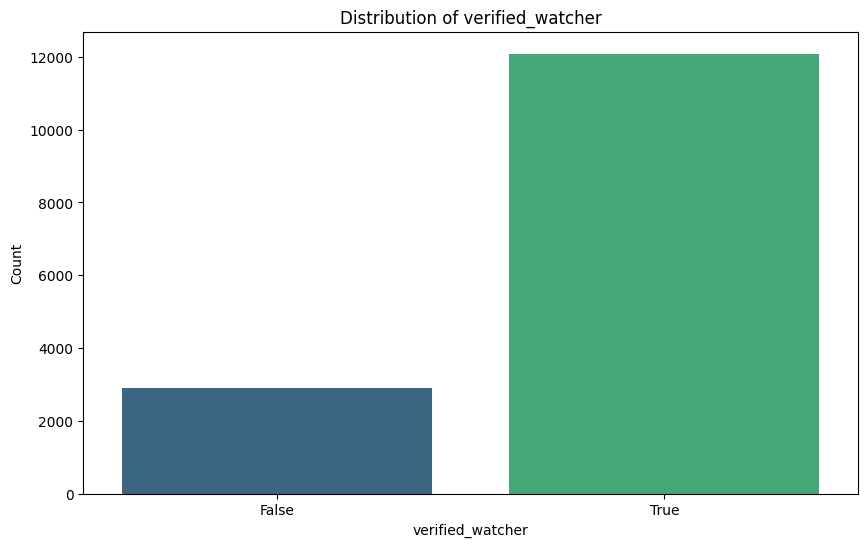

In [7]:
# Visualize the distribution of verified_watcher
plt.figure(figsize=(10, 6))
sns.countplot(x='is_verified_watch', data=new_data, palette='viridis')
plt.title('Distribution of verified_watcher')
plt.xlabel('verified_watcher')
plt.ylabel('Count')
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_2460\286529384.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=new_data, palette='viridis',legend=False)


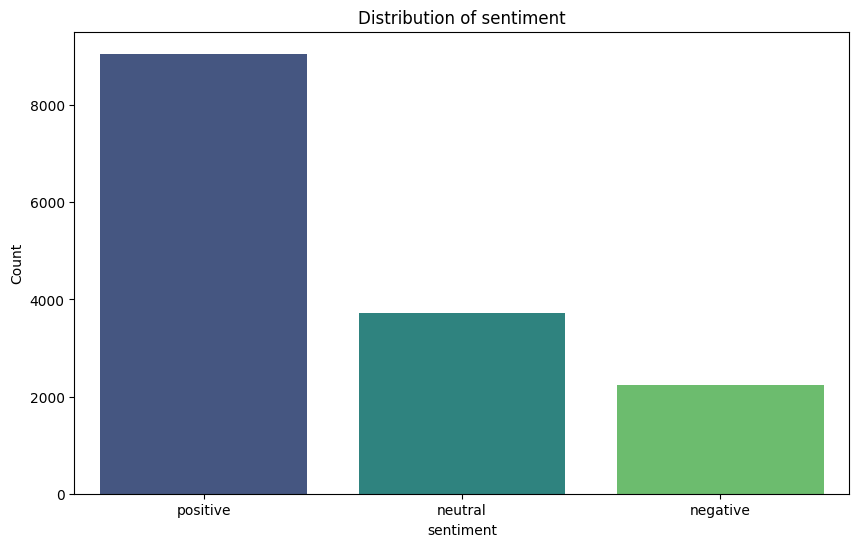

In [8]:
# Visualize the distribution of sentiment
plt.figure(figsize=(10, 6))
sns.countplot(x='sentiment', data=new_data, palette='viridis',legend=False)
plt.title('Distribution of sentiment')
plt.xlabel('sentiment')
plt.ylabel('Count')
plt.show()

### Feature Engineering

In [9]:
### Feature Engineering
### selecting relevant features for analysis
data = ['rating', 'is_verified_watch', 'sentiment', 'review_text']
print("Selected features for analysis:", data)
new_data = new_data[data]
print("New shape of the dataset after feature selection:", new_data.shape)
new_data.head()

Selected features for analysis: ['rating', 'is_verified_watch', 'sentiment', 'review_text']
New shape of the dataset after feature selection: (15000, 4)


,rating,is_verified_watch,sentiment,review_text
0,4,False,positive,Fantastic cinematography and plot twists.
1,5,True,positive,This series is a masterpiece!
2,4,True,positive,Fantastic cinematography and plot twists.
3,5,True,positive,One of the best series I've ever watched. High...
4,3,True,neutral,Mixed feelings about this one.


In [10]:
# in is_verified_watch column, choose only 'True' values
new_data = new_data[new_data['is_verified_watch'] == True]
print("Shape of the dataset after filtering for verified watchers:", new_data.shape)
print("Number of missing values in each column after filtering for verified watchers:")
print(new_data.isnull().sum())
print("")

Shape of the dataset after filtering for verified watchers: (12090, 4)
Number of missing values in each column after filtering for verified watchers:
rating                 0
is_verified_watch      0
sentiment              0
review_text          610
dtype: int64



In [11]:
# remove null values columns
new_data = new_data.dropna(axis=0)
print(new_data.isnull().sum())
print("Columns with null values removed. New shape of the dataset:", new_data.shape)

rating               0
is_verified_watch    0
sentiment            0
review_text          0
dtype: int64
Columns with null values removed. New shape of the dataset: (11480, 4)


In [12]:
new_data.head()

,rating,is_verified_watch,sentiment,review_text
1,5,True,positive,This series is a masterpiece!
2,4,True,positive,Fantastic cinematography and plot twists.
3,5,True,positive,One of the best series I've ever watched. High...
4,3,True,neutral,Mixed feelings about this one.
5,3,True,neutral,Okay for a one-time watch.


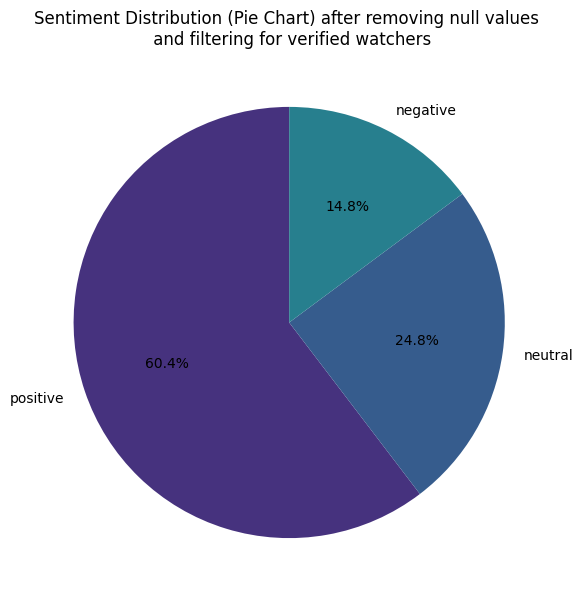

In [13]:
# Pie chart for sentiment distribution
plt.figure(figsize=(7, 7))
new_data['sentiment'].value_counts().plot.pie(autopct='%1.1f%%', colors=sns.color_palette('viridis'), startangle=90)
plt.title('Sentiment Distribution (Pie Chart) after removing null values \n and filtering for verified watchers')
plt.ylabel('')
plt.show()

In [ ]:
new_data_neutral = new_data[new_data['sentiment'] == 'neutral']
new_data_positive = new_data[new_data['sentiment'] == 'positive']
new_data_negative = new_data[new_data['sentiment'] == 'negative']

In [15]:
! pip install wordcloud


[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


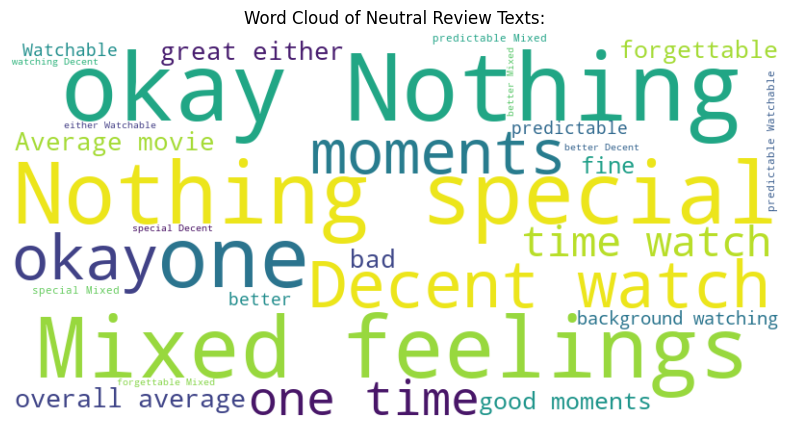

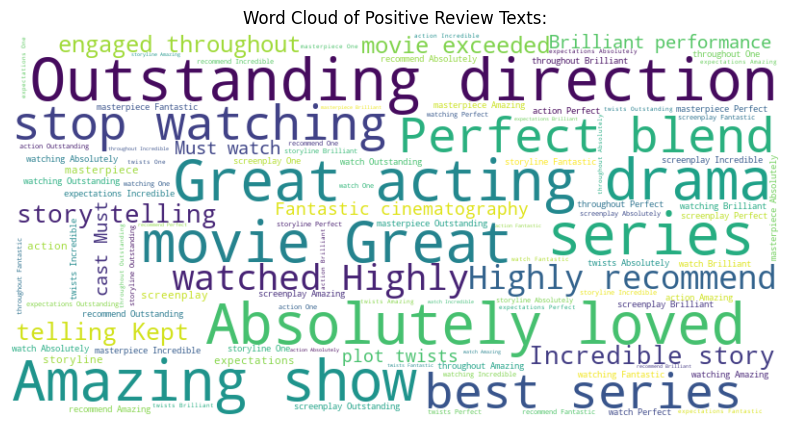

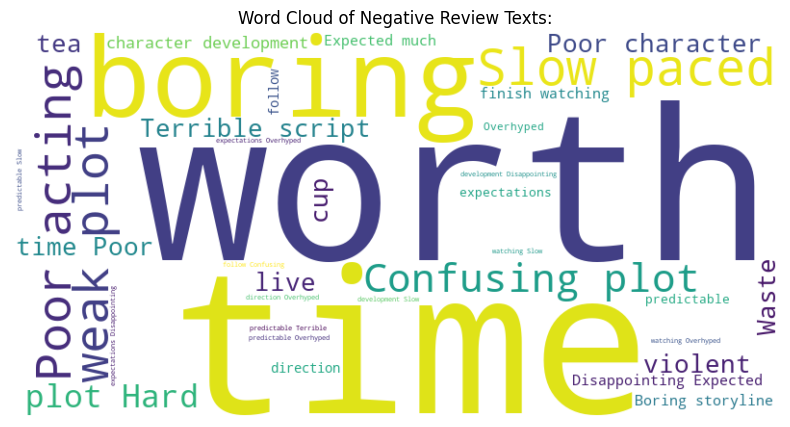

In [25]:
from wordcloud import WordCloud

# Combine all review texts into one string

for i in [new_data_neutral, new_data_positive, new_data_negative]:
    text = " ".join(i['review_text'].dropna().astype(str))

    # Generate word cloud
    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    if i.equals(new_data_neutral):
        plt.title('Word Cloud of Neutral Review Texts:')
    elif i.equals(new_data_positive):
        plt.title('Word Cloud of Positive Review Texts:')
    else:
        plt.title('Word Cloud of Negative Review Texts:')
    plt.show()

In [30]:
data = ['sentiment', 'review_text']
print("Selected features for model prediction:", data)
new_data = new_data[data]

# save the cleaned data to a new csv file
new_data.to_csv('cleaned_reviews(sentiment and review_text).csv', index=False)


Selected features for model prediction: ['sentiment', 'review_text']
